<a href="https://colab.research.google.com/github/riya1606/NLP_Resume_Parser/blob/main/NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/grive')

Drive already mounted at /content/grive; to attempt to forcibly remount, call drive.mount("/content/grive", force_remount=True).


In [7]:
import spacy
import pickle
import random
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import math
import nltk
from textblob import TextBlob as tb
warnings.filterwarnings('ignore')
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from pandas.plotting import scatter_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [8]:
data1 = pd.read_csv("/content/grive/MyDrive/nlp_review/UpdatedResumeDataSet.csv")

In [9]:
infile = open('/content/grive/MyDrive/nlp_review/train_data.pkl','rb')
train_data = pickle.load(infile)

In [10]:
train_data[0]

('Govardhana K Senior Software Engineer  Bengaluru, Karnataka, Karnataka - Email me on Indeed: indeed.com/r/Govardhana-K/ b2de315d95905b68  Total IT experience 5 Years 6 Months Cloud Lending Solutions INC 4 Month • Salesforce Developer Oracle 5 Years 2 Month • Core Java Developer Languages Core Java, Go Lang Oracle PL-SQL programming, Sales Force Developer with APEX.  Designations & Promotions  Willing to relocate: Anywhere  WORK EXPERIENCE  Senior Software Engineer  Cloud Lending Solutions -  Bangalore, Karnataka -  January 2018 to Present  Present  Senior Consultant  Oracle -  Bangalore, Karnataka -  November 2016 to December 2017  Staff Consultant  Oracle -  Bangalore, Karnataka -  January 2014 to October 2016  Associate Consultant  Oracle -  Bangalore, Karnataka -  November 2012 to December 2013  EDUCATION  B.E in Computer Science Engineering  Adithya Institute of Technology -  Tamil Nadu  September 2008 to June 2012  https://www.indeed.com/r/Govardhana-K/b2de315d95905b68?isid=rex-

In [21]:
nlp=spacy.blank('en')

def train_model(train_data):
  if 'ner' not in nlp.pipe_names:
    nlp.add_pipe('ner', last=True)
  ner = nlp.get_pipe('ner') # Get the NER component regardless of whether it was just added or already existed

# We add labels in the NLP Pipelines
  for _, annotation in train_data:
    for ent in annotation['entities']:
      ner.add_label(ent[2])

# get names of other pipes to disable them during training
  other_pipes = [pipe for pipe in nlp.pipe_names if pipe != 'ner']
  with nlp.disable_pipes(*other_pipes):
    optimizer = nlp.begin_training()
    for itn in range(10):
      print("Starting iteration "+str(itn))
      random.shuffle(train_data)
      losses = {}
      index=0
      for text, annotations in train_data:
        # print (index)
        try:
          nlp.update(
              [text], #batch of texts
              [annotations], # batch of annotations
              drop=0.2, #dropout - make it harder to memorise
              sgd=optimizer, #callable to update weights
              losses=losses
          )
        except Exception as e:
          pass
            # print(text)

      print(losses)

In [22]:
train_model(train_data)

Starting iteration 0
{}
Starting iteration 1
{}
Starting iteration 2
{}
Starting iteration 3
{}
Starting iteration 4
{}
Starting iteration 5
{}
Starting iteration 6
{}
Starting iteration 7
{}
Starting iteration 8
{}
Starting iteration 9
{}


In [23]:
nlp.to_disk('nlp_model')

In [24]:
nlp_model = spacy.load('nlp_model')

In [25]:
train_data[1]

('Mansi Thanki Student  Jamnagar, Gujarat - Email me on Indeed: indeed.com/r/Mansi-Thanki/04b8914a81df5a81  project on "Water Quality Of Different Areas Of Ahmedabad City  WORK EXPERIENCE  Microsoft Excel, Microsoft Power Point, Microsoft Word, File Management, Internet Use and C  15 days training at Tata Chemicals Limited -  Mithapur, Gujarat  Mithapur (during 6th Sem) Computer Skill: Microsoft Excel, Microsoft Power Point, Microsoft Word, File Management, Internet Use and C language  EDUCATION  BE in Environmental Engineering  Government Engineering College Bhuj -  Bhuj, Gujarat  2009 to 2013  https://www.indeed.com/r/Mansi-Thanki/04b8914a81df5a81?isid=rex-download&ikw=download-top&co=IN',
 {'entities': [(533, 568, 'College Name'),
   (500, 531, 'Degree'),
   (22, 30, 'Location'),
   (13, 20, 'Designation'),
   (0, 12, 'Name')]})

In [26]:
doc = nlp_model(train_data[0][0])
for ent in doc.ents:
  print(f'{ent.label_.upper():{30}}-{ent.text}')


In [28]:
!pip install PyMuPDF


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 72.8 MB/s eta 0:00:00


In [31]:
!pip install PyMuPDF
import sys, fitz
fname = '/content/grive/MyDrive/nlp_review/Alice Clark CV.pdf'
doc = fitz.open(fname)
text = ""
for page in doc:
  text = text + str(page.get_text())

tx = " ".join(text.split('\n'))
print(tx)


Alice Clark  AI / Machine Learning    Delhi, India Email me on Indeed  •  20+ years of experience in data handling, design, and development  •  Data Warehouse: Data analysis, star/snow flake scema data modelling and design specific to  data warehousing and business intelligence  •  Database: Experience in database designing, scalability, back-up and recovery, writing and  optimizing SQL code and Stored Procedures, creating functions, views, triggers and indexes.  Cloud platform: Worked on Microsoft Azure cloud services like Document DB, SQL Azure,  Stream Analytics, Event hub, Power BI, Web Job, Web App, Power BI, Azure data lake  analytics(U-SQL)  Willing to relocate anywhere    WORK EXPERIENCE  Software Engineer  Microsoft – Bangalore, Karnataka  January 2000 to Present  1. Microsoft Rewards Live dashboards:  Description: - Microsoft rewards is loyalty program that rewards Users for browsing and shopping  online. Microsoft Rewards members can earn points when searching with Bing, bro

In [32]:
doc = nlp_model(tx)
for ent in doc.ents:
  print(f'{ent.label_.upper():{30}}-{ent.text}')

In [ ]:
data1['cleaned_resume'] = ''
data1.head()

,Category,Resume,cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",


In [33]:
print ("Displaying the distinct categories of resume:\n\n ")
print (data1['Category'].unique())

Displaying the distinct categories of resume:

 
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [34]:
print ("Displaying the distinct categories of resume and the number of records belonging to each category:\n\n")
print (data1['Category'].value_counts())

Displaying the distinct categories of resume and the number of records belonging to each category:


Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


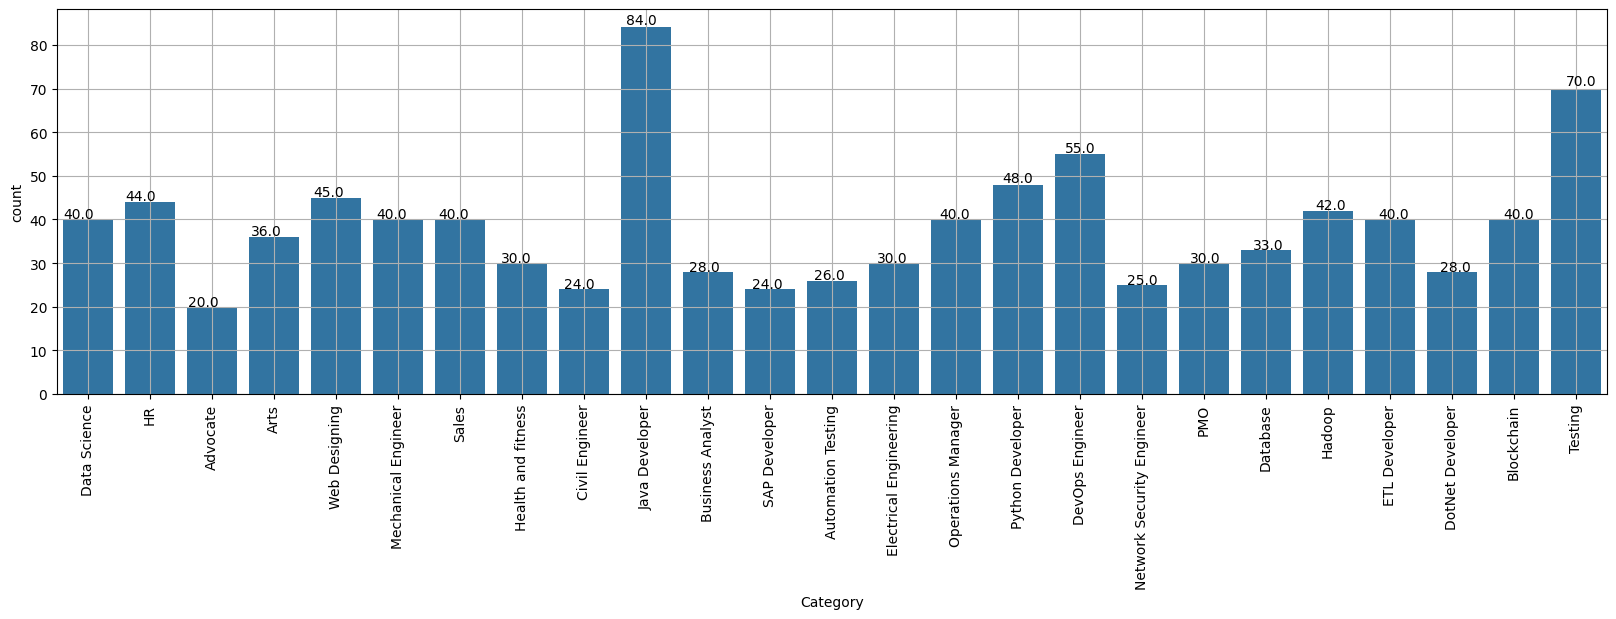

In [35]:
import seaborn as sns
plt.figure(figsize=(20,5))
plt.xticks(rotation=90)
ax=sns.countplot(x="Category", data=data1)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
plt.grid()

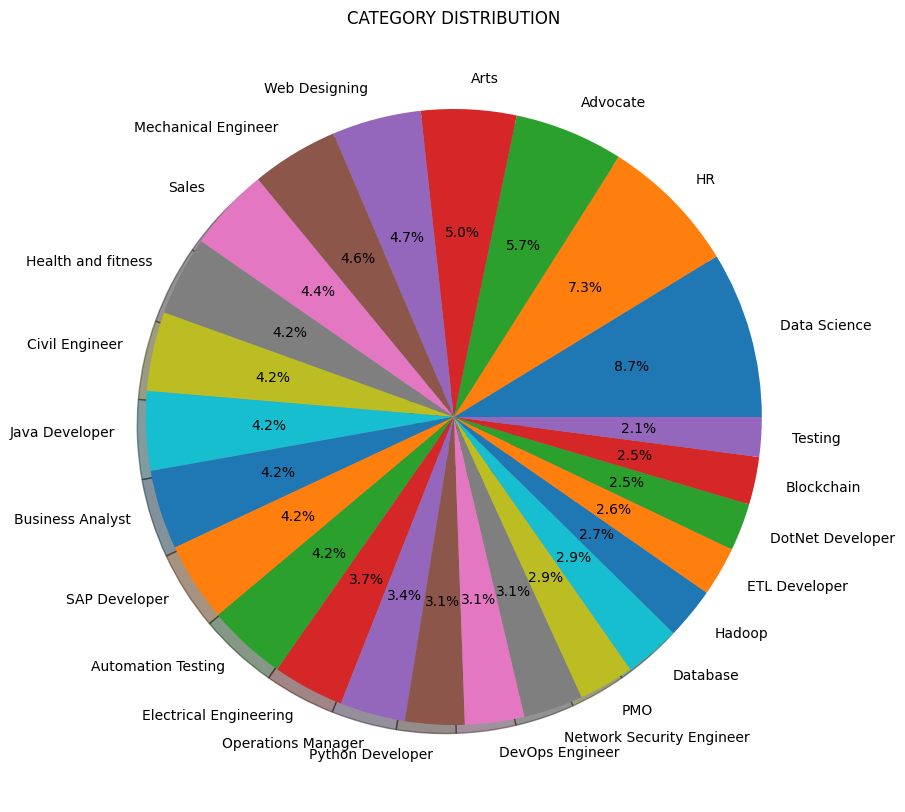

In [36]:
from matplotlib.gridspec import GridSpec
targetCounts = data1['Category'].value_counts()
targetLabels  = data1['Category'].unique()
# Make square figures and axes
plt.figure(1, figsize=(22,22))
the_grid = GridSpec(2, 2)


cmap = plt.get_cmap('coolwarm')
plt.subplot(the_grid[0, 1], aspect=1, title='CATEGORY DISTRIBUTION')

source_pie = plt.pie(targetCounts, labels=targetLabels, autopct='%1.1f%%', shadow=True)
plt.show()

In [37]:
doc1=tb(train_data[0][0])
doc2=tb(train_data[1][0])
doc3=tb(train_data[2][0])
doc4=tb(train_data[3][0])
doc5=tb(train_data[4][0])


In [38]:
train_data[0][0]

'Puneet Bhandari SAP SD lead - Microsoft IT  Pune, Maharashtra - Email me on Indeed: indeed.com/r/Puneet-Bhandari/c9002fa44d6760bd  Willing to relocate: Anywhere  WORK EXPERIENCE  SAP SD lead  Microsoft IT -  August 2010 to Present  Team Size: 8 Duration: Seven months  Scope: * Enhancement of Mexico invoicing process as per the current regulations * Requirement gathering from third party and client on new process * Responsible for implementing the changes in system  Area of Exposure: * Understand the AS-IS process and develop to- Be design document to meet the business and Government requirement * Requirement gathering for all SD process for client * Developed solution blueprint and Process Design Documents for OTC 3-way and 1-way invoice processes * Interacting with third party to gather requirements from their end * Creating functional specification and Gap analysis document for different country implementation with client * Design test scripts for functional unit testing (FUT), Inte

In [39]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [40]:
def tf(word,blob):
  return blob.words.count(word)/len(blob.words)
  ## the number of documents containing the word

def n_containing(word,bloblist):
  return sum(1 for blob in bloblist if word in blob.words)

def idf(word,bloblist):
  return math.log(len(bloblist)/(1+n_containing(word,bloblist)))

def tfidf(word,blob,bloblist):
  return tf(word,blob)*idf(word,bloblist)

In [43]:
import nltk
nltk.download('punkt_tab')
bloblist = [doc1,doc2,doc3,doc4,doc5]
for i, blob in enumerate(bloblist):
  print("Top resumes in the lot:")
  scores= {word: tfidf(word,blob,bloblist) for word in blob.words}
  sorted_words= sorted(scores.items(), key=lambda x:x[1], reverse=True)
  for word, score in sorted_words[:3]:
    print("\tWord: {},TF-IDF:{}".format(word,round(score,5)))
  print("\n")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Top resumes in the lot:
	Word: SD,TF-IDF:0.01236
	Word: Sd,TF-IDF:0.01236
	Word: Sap,TF-IDF:0.01004


Top resumes in the lot:
	Word: Gujarat,TF-IDF:0.03312
	Word: Excel,TF-IDF:0.02208
	Word: Power,TF-IDF:0.02208


Top resumes in the lot:
	Word: To,TF-IDF:0.03004
	Word: ➢,TF-IDF:0.02816
	Word: And,TF-IDF:0.02617


Top resumes in the lot:
	Word: •,TF-IDF:0.02467
	Word: And,TF-IDF:0.02427
	Word: With,TF-IDF:0.02031


Top resumes in the lot:
	Word: Patna,TF-IDF:0.0833
	Word: Bihar,TF-IDF:0.0833
	Word: BSc,TF-IDF:0.04165




In [83]:
docc1 = train_data[0][0]
docc2 = train_data[1][0]
docc3 = train_data[2][0]
docc1

'Puneet Bhandari SAP SD lead - Microsoft IT  Pune, Maharashtra - Email me on Indeed: indeed.com/r/Puneet-Bhandari/c9002fa44d6760bd  Willing to relocate: Anywhere  WORK EXPERIENCE  SAP SD lead  Microsoft IT -  August 2010 to Present  Team Size: 8 Duration: Seven months  Scope: * Enhancement of Mexico invoicing process as per the current regulations * Requirement gathering from third party and client on new process * Responsible for implementing the changes in system  Area of Exposure: * Understand the AS-IS process and develop to- Be design document to meet the business and Government requirement * Requirement gathering for all SD process for client * Developed solution blueprint and Process Design Documents for OTC 3-way and 1-way invoice processes * Interacting with third party to gather requirements from their end * Creating functional specification and Gap analysis document for different country implementation with client * Design test scripts for functional unit testing (FUT), Inte

In [84]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords')

X ="Microsoft".lower()
Y =docc1.lower()

# tokenization
X_list = word_tokenize(X)
Y_list = word_tokenize(Y)

# sw contains the list of stopwords
sw = stopwords.words('english')
l1 =[];l2 =[]

# remove stop words from the string
X_set = {w for w in X_list if not w in sw}
Y_set = {w for w in Y_list if not w in sw}

# form a set containing keywords of both strings
rvector = X_set.union(Y_set)
for w in rvector:
    if w in X_set: l1.append(1) # create a vector
    else: l1.append(0)
    if w in Y_set: l2.append(1)
    else: l2.append(0)
c = 0

# cosine formula
for i in range(len(rvector)):
        c+= l1[i]*l2[i]
cosine = c / float((sum(l1)*sum(l2))**0.5)
print("similarity: ", cosine)


similarity:  0.04885319687460315


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [88]:
docc2

'Mansi Thanki Student  Jamnagar, Gujarat - Email me on Indeed: indeed.com/r/Mansi-Thanki/04b8914a81df5a81  project on "Water Quality Of Different Areas Of Ahmedabad City  WORK EXPERIENCE  Microsoft Excel, Microsoft Power Point, Microsoft Word, File Management, Internet Use and C  15 days training at Tata Chemicals Limited -  Mithapur, Gujarat  Mithapur (during 6th Sem) Computer Skill: Microsoft Excel, Microsoft Power Point, Microsoft Word, File Management, Internet Use and C language  EDUCATION  BE in Environmental Engineering  Government Engineering College Bhuj -  Bhuj, Gujarat  2009 to 2013  https://www.indeed.com/r/Mansi-Thanki/04b8914a81df5a81?isid=rex-download&ikw=download-top&co=IN'

In [89]:
X ="Customer Care".lower()
Y =docc2.lower()

# tokenization
X_list = word_tokenize(X)
Y_list = word_tokenize(Y)

# sw contains the list of stopwords
sw = stopwords.words('english')
l1 =[];l2 =[]

# remove stop words from the string
X_set = {w for w in X_list if not w in sw}
Y_set = {w for w in Y_list if not w in sw}

# form a set containing keywords of both strings
rvector = X_set.union(Y_set)
for w in rvector:
    if w in X_set: l1.append(1) # create a vector
    else: l1.append(0)
    if w in Y_set: l2.append(1)
    else: l2.append(0)
c = 0

# cosine formula
for i in range(len(rvector)):
        c+= l1[i]*l2[i]
cosine = c / float((sum(l1)*sum(l2))**0.5)
print("similarity: ", cosine)


similarity:  0.0


In [78]:
docc3

'Shaik Tazuddin Senior Process Executive - STAR India  Bengaluru, Karnataka - Email me on Indeed: indeed.com/r/Shaik-Tazuddin/1366179051f145eb  To establish myself as a sincere and honest employee in a challenging organization by using my attitude and learning, thus enhancing my skills along with the growth of the organization.  WORK EXPERIENCE  Senior Process Executive  STAR India -  Bengaluru, Karnataka -  November 2017 to Present  Senior Process Executive - Cisco Client STAR EMEAR &amp; US: ➢ Creating Dart ID from the requested details and configuring products with appropriate pricing &amp; discounts. ➢ Responsible for managing and analyzing backlog for the European countries with especial attention to France, Spain, United Kingdom, Italy, Sweden, Slovakia, Israel, Germany. ➢ Reviewing quality figures, counts and Q flow monthly to ensure the targets are met. ➢ Making report and C-SAT presentation regarding process for business development. ➢ Immediate action on customer queries and 

In [87]:
X ="Sales".lower()
Y =docc3.lower()

# tokenization
X_list = word_tokenize(X)
Y_list = word_tokenize(Y)

# sw contains the list of stopwords
sw = stopwords.words('english')
l1 =[];l2 =[]

# remove stop words from the string
X_set = {w for w in X_list if not w in sw}
Y_set = {w for w in Y_list if not w in sw}

# form a set containing keywords of both strings
rvector = X_set.union(Y_set)
for w in rvector:
    if w in X_set: l1.append(1) # create a vector
    else: l1.append(0)
    if w in Y_set: l2.append(1)
    else: l2.append(0)
c = 0

# cosine formula
for i in range(len(rvector)):
        c+= l1[i]*l2[i]
cosine = c / float((sum(l1)*sum(l2))**0.5)
print("similarity: ", cosine)


similarity:  0.0657951694959769
